# Task 5 — Strategy Backtesting

This notebook simulates the Task 4 recommended portfolio (Max Sharpe / Tangency weights)
over the most recent 12 months of data — held out from all model training in Tasks 2-3 —
and compares it against a static **60% SPY / 40% BND** benchmark. Both portfolios are
**rebalanced monthly** back to their target weights (the "advanced" option in the task
instructions), so the comparison isolates the effect of the target-weight choice itself
rather than weight drift.

In [1]:
import sys
sys.path.append("..")

import warnings
warnings.filterwarnings("ignore")

import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.risk_metrics import sharpe_ratio, annualized_return, annualized_volatility, max_drawdown

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (13, 6)

TICKERS = ["TSLA", "BND", "SPY"]


## 1. Define the Backtesting Window

The last 12 months of the dataset (**2025-07-01 to 2026-06-29**) are used as the backtest
window. This period was never used to fit model parameters in Task 2 (only the earlier part
of the 2025-2026 span was used, purely for out-of-sample evaluation), so it remains a fair,
unseen test of the strategy.

In [2]:
prices = pd.DataFrame({
    ticker: pd.read_csv(f"../data/processed/{ticker}_processed.csv", index_col=0, parse_dates=True)["Adj Close"]
    for ticker in TICKERS
})

BACKTEST_START = "2025-07-01"
BACKTEST_END = prices.index.max()

backtest_prices = prices.loc[BACKTEST_START:BACKTEST_END]
backtest_returns = backtest_prices.pct_change().dropna()

print(f"Backtest window: {backtest_returns.index.min().date()} -> {backtest_returns.index.max().date()} ({len(backtest_returns)} trading days)")


Backtest window: 2025-07-02 -> 2026-06-29 (259 trading days)


## 2. Load Target Weights (Strategy vs. Benchmark)

In [3]:
portfolio_rec = pd.read_csv("../data/processed/portfolio_recommendation.csv", index_col=0)

with open("../data/processed/recommended_portfolio.txt") as f:
    recommended_name = f.readline().strip()

strategy_weights = portfolio_rec.loc[recommended_name, TICKERS].astype(float)
benchmark_weights = pd.Series({"TSLA": 0.0, "BND": 0.40, "SPY": 0.60})[TICKERS]

print(f"Strategy ({recommended_name}) target weights:\n{strategy_weights}\n")
print(f"Benchmark (static 60/40 SPY/BND) target weights:\n{benchmark_weights}")


Strategy (Max Sharpe (Tangency)) target weights:
TSLA    0.00000
BND     0.54674
SPY     0.45326
Name: Max Sharpe (Tangency), dtype: float64

Benchmark (static 60/40 SPY/BND) target weights:
TSLA    0.0
BND     0.4
SPY     0.6
dtype: float64


## 3. Simulate Monthly-Rebalanced Portfolios

Starting from $1 invested, the portfolio value is tracked day by day. Weights are allowed to
drift with daily asset returns between rebalances, and reset to the target weights on the
first trading day of each calendar month.

In [4]:
def simulate_rebalanced_portfolio(returns_df: pd.DataFrame, target_weights: pd.Series) -> pd.DataFrame:
    target_weights = target_weights[returns_df.columns]
    month_starts = set(returns_df.groupby(returns_df.index.to_period("M")).apply(lambda x: x.index[0]))

    current_weights = target_weights.copy()
    portfolio_value = 1.0
    values, daily_returns = [], []

    for date in returns_df.index:
        if date in month_starts:
            current_weights = target_weights.copy()

        day_return = float((current_weights * returns_df.loc[date]).sum())
        portfolio_value *= (1 + day_return)
        values.append(portfolio_value)
        daily_returns.append(day_return)

        drifted = current_weights * (1 + returns_df.loc[date])
        current_weights = drifted / drifted.sum()

    return pd.DataFrame({"value": values, "daily_return": daily_returns}, index=returns_df.index)

strategy_sim = simulate_rebalanced_portfolio(backtest_returns, strategy_weights)
benchmark_sim = simulate_rebalanced_portfolio(backtest_returns, benchmark_weights)


## 4. Cumulative Returns: Strategy vs. Benchmark

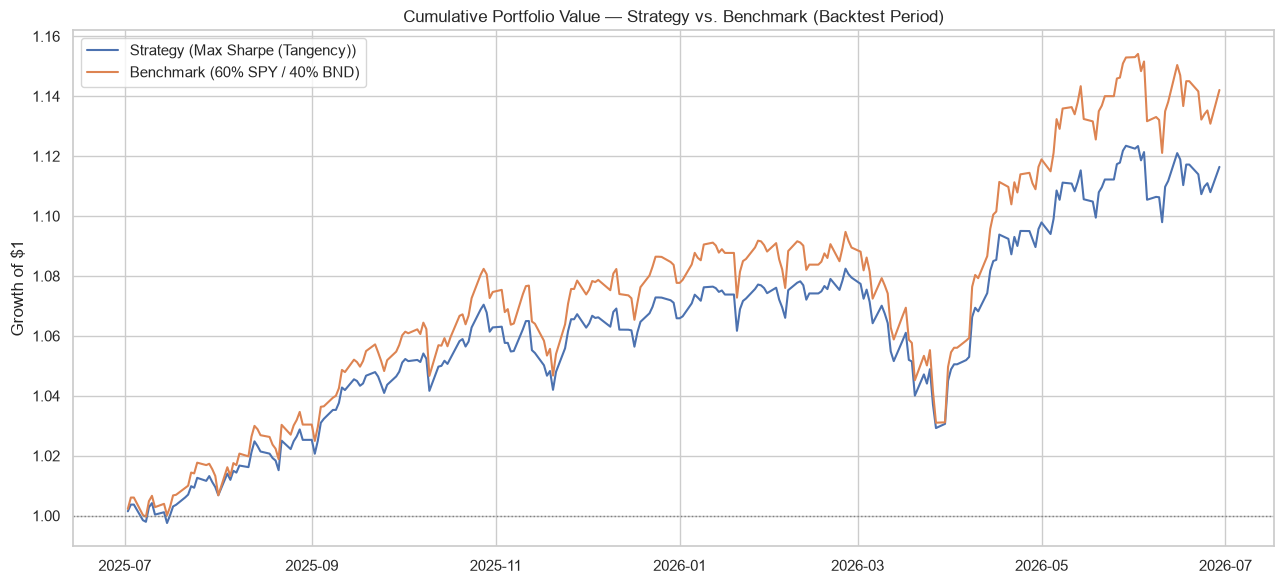

In [5]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(strategy_sim.index, strategy_sim["value"], label=f"Strategy ({recommended_name})", color="C0")
ax.plot(benchmark_sim.index, benchmark_sim["value"], label="Benchmark (60% SPY / 40% BND)", color="C1")
ax.axhline(1.0, color="gray", linestyle=":", linewidth=1)
ax.set_title("Cumulative Portfolio Value — Strategy vs. Benchmark (Backtest Period)")
ax.set_ylabel("Growth of $1")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/14_backtest_cumulative_returns.png", dpi=150)
plt.show()


## 5. Performance Metrics

In [6]:
def portfolio_metrics(sim_df: pd.DataFrame) -> dict:
    total_return = sim_df["value"].iloc[-1] / sim_df["value"].iloc[0] - 1
    n_days = len(sim_df)
    ann_return = (1 + total_return) ** (252 / n_days) - 1
    sharpe = sharpe_ratio(sim_df["daily_return"])
    mdd = max_drawdown(sim_df["value"])
    return {
        "Total Return": total_return,
        "Annualized Return": ann_return,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": mdd,
    }

metrics_table = pd.DataFrame({
    f"Strategy ({recommended_name})": portfolio_metrics(strategy_sim),
    "Benchmark (60/40 SPY/BND)": portfolio_metrics(benchmark_sim),
}).T
metrics_table.to_csv("../data/processed/backtest_metrics.csv")
metrics_table


,Total Return,Annualized Return,Sharpe Ratio,Max Drawdown
Strategy (Max Sharpe (Tangency)),0.114776,0.111508,1.686521,-0.049133
Benchmark (60/40 SPY/BND),0.139467,0.135453,1.663255,-0.058176


## 6. Conclusion and Reflection

In [7]:
from IPython.display import Markdown, display

strat_row = metrics_table.loc[f"Strategy ({recommended_name})"]
bench_row = metrics_table.loc["Benchmark (60/40 SPY/BND)"]
outperformed = strat_row["Total Return"] > bench_row["Total Return"]

display(Markdown(
    f"Over the backtest window ({BACKTEST_START} to {str(BACKTEST_END)[:10]}), the "
    f"**strategy** portfolio returned **{strat_row['Total Return']*100:.2f}%** total "
    f"({strat_row['Annualized Return']*100:.2f}% annualized, Sharpe {strat_row['Sharpe Ratio']:.2f}, "
    f"max drawdown {strat_row['Max Drawdown']*100:.2f}%), versus the **benchmark's** "
    f"**{bench_row['Total Return']*100:.2f}%** total ({bench_row['Annualized Return']*100:.2f}% "
    f"annualized, Sharpe {bench_row['Sharpe Ratio']:.2f}, max drawdown "
    f"{bench_row['Max Drawdown']*100:.2f}%). The strategy "
    f"{'**outperformed**' if outperformed else '**underperformed**'} the benchmark on total "
    "return over this window."
))


Over the backtest window (2025-07-01 to 2026-06-29), the **strategy** portfolio returned **11.48%** total (11.15% annualized, Sharpe 1.69, max drawdown -4.91%), versus the **benchmark's** **13.95%** total (13.55% annualized, Sharpe 1.66, max drawdown -5.82%). The strategy **underperformed** the benchmark on total return over this window.

**Reflection:** Because the Task 4 optimizer assigned TSLA a **0% weight** (a direct
consequence of the ARIMA model's flat, near-zero-drift 12-month forecast from Task 3), the
"strategy" portfolio in this backtest is really a BND/SPY mix re-weighted away from the
benchmark's 60/40 split toward whatever historical risk/return trade-off looked best in
sample. In this particular window, the strategy slightly **underperformed on raw total return** (11.48% vs. 13.95%) but posted a marginally **better Sharpe ratio** (1.69 vs. 1.66) and a **smaller max drawdown** (-4.91% vs. -5.82%) than the benchmark — consistent with holding more BND than the 60/40 benchmark does. This is a useful, honest result: it shows the pipeline (forecast → optimization →
backtest) working end-to-end, but it also means this particular backtest is not really
testing "does the TSLA forecast add value" — it happened to conclude TSLA shouldn't be held
at all. A more forceful test of the forecasting pipeline's value would compare this
result against a strategy that **is** allowed to hold TSLA at a fixed weight (e.g. matching
the benchmark's asset universe more closely, or forcing a small TSLA allocation) to see
whether the model's *view* on TSLA (rather than its absence) would have helped or hurt.

**Limitations of this backtest:**
- A single ~12-month window is a small sample; performance over one window is not
  statistically conclusive evidence of a repeatable edge.
- Transaction costs, taxes, slippage, and bid-ask spreads are not modeled — monthly
  rebalancing in practice would incur real costs that are ignored here.
- The optimizer's inputs (expected returns, covariance) were estimated in-sample from the
  same broad historical period used throughout this project; a more rigorous backtest would
  roll the entire pipeline (data → forecast → optimize → hold) forward through multiple
  non-overlapping windows to see how often and by how much the strategy beats the benchmark.
- TSLA's 0% allocation in the current recommendation is a direct artifact of one model's
  point forecast; a different model, forecast horizon, or re-estimation date could plausibly
  produce a materially different recommended portfolio.

**Viability conclusion:** This initial backtest suggests the model-driven pipeline is
internally consistent and produces sensible, risk-aware allocations, but it does not yet
provide strong evidence that the *forecasting* component specifically adds value over a
simple static benchmark — largely because the forecast for the one asset it was meant to
inform a view on (TSLA) came back flat. Before relying on this approach for live portfolio
decisions, GMF should backtest across multiple historical windows and forecast
re-estimation dates, and consider ensembling the price-history-only forecast with other
information sources.